In [13]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [16]:
# Load Dataset
path = r'C:\Users\User\Dropbox\Term 2252\ARTI 308\Labs\lab3\dataset\sales.csv'
df = pd.read_csv( path , encoding = 'Latin-1')

# Display first 5 rows
df.head()

,Area Code,State,Market,Market Size,Profit,Margin,Sales,COGS,Total Expenses,Marketing,Inventory,Budget Profit,Budget COGS,Budget Margin,Budget Sales,ProductId,Date,Product Type,Product,Type
0,203,Connecticut,East,Small Market,107.0,176.0,292.0,116.0,69.0,38.0,962.0,110.0,110.0,160.0,270.0,2,04/01/10 00:00:00,Coffee,Columbian,Regular
1,203,Connecticut,East,Small Market,75.0,135.0,225.0,90.0,60.0,29.0,1148.0,90.0,80.0,130.0,210.0,2,07/01/10 00:00:00,Coffee,Columbian,Regular
2,203,Connecticut,East,Small Market,122.0,195.0,325.0,130.0,73.0,42.0,1134.0,130.0,110.0,180.0,290.0,2,11/01/10 00:00:00,Coffee,Columbian,Regular
3,203,Connecticut,East,Small Market,105.0,174.0,289.0,115.0,69.0,37.0,1166.0,110.0,100.0,160.0,260.0,2,12/01/10 00:00:00,Coffee,Columbian,Regular
4,203,Connecticut,East,Small Market,104.0,135.0,223.0,90.0,56.0,29.0,1148.0,90.0,80.0,130.0,210.0,2,07/01/11 00:00:00,Coffee,Columbian,Regular


### Check Missing Values

In [17]:
# Check all values
print(df.isna())

      Area Code  State  Market  Market Size  Profit  Margin  Sales   COGS  \
0         False  False   False        False   False   False  False  False   
1         False  False   False        False   False   False  False  False   
2         False  False   False        False   False   False  False  False   
3         False  False   False        False   False   False  False  False   
4         False  False   False        False   False   False  False  False   
...         ...    ...     ...          ...     ...     ...    ...    ...   
4243      False  False   False        False   False   False  False  False   
4244      False  False   False        False   False   False  False  False   
4245      False  False   False        False   False   False  False  False   
4246      False  False   False        False   False   False  False  False   
4247      False  False   False        False   False   False  False  False   

      Total Expenses  Marketing  Inventory  Budget Profit  Budget COGS  \
0

In [18]:
print(df.isna().sum())

Area Code         0
State             0
Market            0
Market Size       0
Profit            0
Margin            0
Sales             0
COGS              0
Total Expenses    0
Marketing         0
Inventory         0
Budget Profit     0
Budget COGS       0
Budget Margin     0
Budget Sales      0
ProductId         0
Date              0
Product Type      0
Product           0
Type              0
dtype: int64


### Check duplicate rows

In [19]:
# checking duplicate rows
df.duplicated()[df.duplicated()==True]

Series([], dtype: bool)

### No. of rows and columns

In [20]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (4248, 20) 

number of rows:  4248
number of columns:  20


### Data type of columns

In [21]:
# viewing the data types of columns
df.dtypes

Area Code           int64
State              object
Market             object
Market Size        object
Profit            float64
Margin            float64
Sales             float64
COGS              float64
Total Expenses    float64
Marketing         float64
Inventory         float64
Budget Profit     float64
Budget COGS       float64
Budget Margin     float64
Budget Sales      float64
ProductId           int64
Date               object
Product Type       object
Product            object
Type               object
dtype: object

In [ ]:
# Statistical summary
df.describe(include='all')

### Univariate Analysis

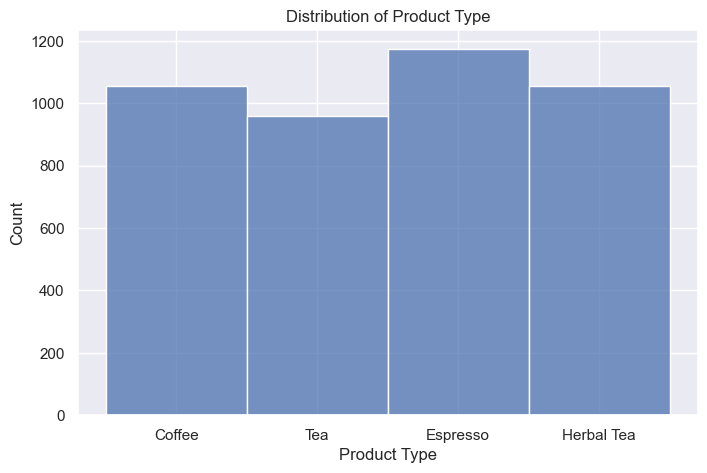

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df['Product Type'], bins=20)
plt.title("Distribution of Product Type")
plt.show()

### Distribution of Revenue

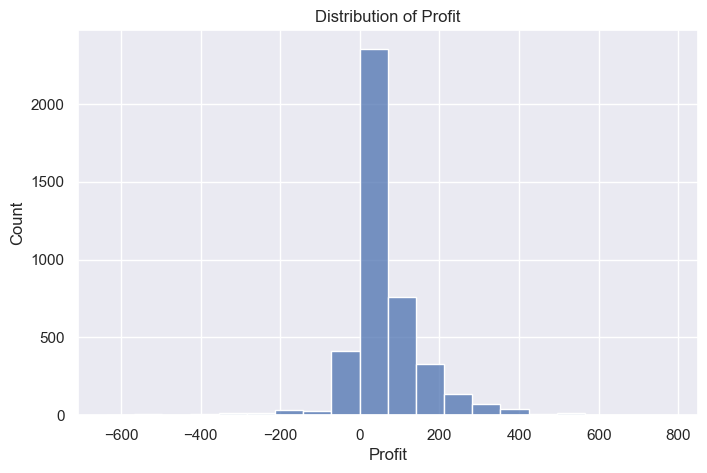

In [40]:
plt.figure(figsize=(8,5))
sns.histplot(df['Profit'], bins=20)
plt.title("Distribution of Profit")
plt.show()

## Bivariate Analysis

### Revenue by Market Size

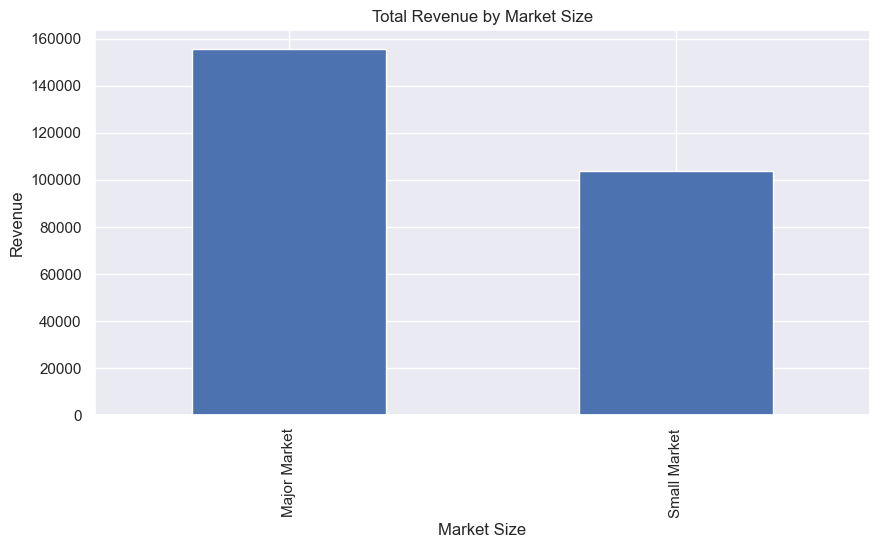

Market Size
Major Market    155736.0
Small Market    103807.0
Name: Profit, dtype: float64

In [30]:
Market_revenue = df.groupby('Market Size')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
Market_revenue.plot(kind='bar')
plt.title("Total Revenue by Market Size")
plt.ylabel("Revenue")
plt.show()

country_revenue

### Sales of Product

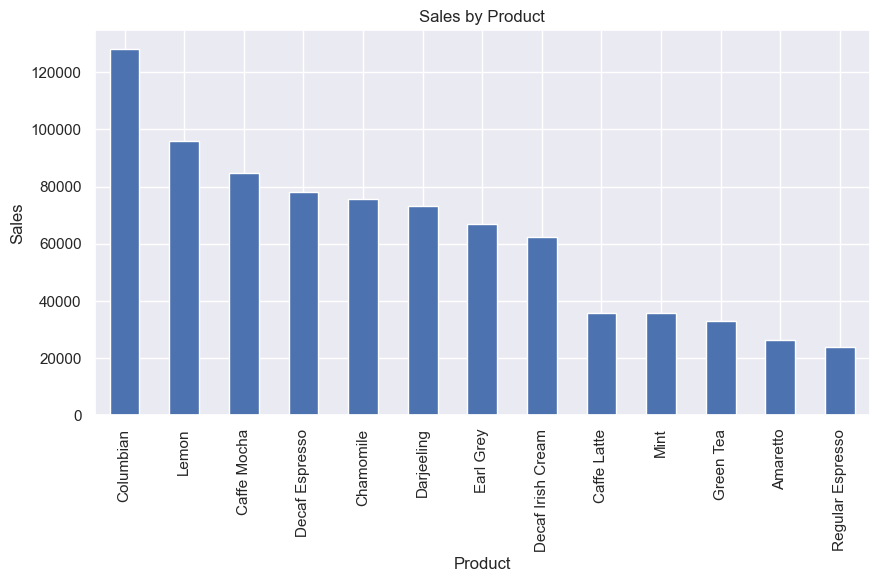

Product
Columbian            128311.0
Lemon                 95926.0
Caffe Mocha           84904.0
Decaf Espresso        78162.0
Chamomile             75578.0
Darjeeling            73151.0
Earl Grey             66772.0
Decaf Irish Cream     62248.0
Caffe Latte           35899.0
Mint                  35710.0
Green Tea             32850.0
Amaretto              26269.0
Regular Espresso      24031.0
Name: Sales, dtype: float64

In [33]:
product_sales = df.groupby('Product')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
product_sales.plot(kind='bar')
plt.title("Sales by Product")
plt.ylabel("Sales")
plt.show()

product_sales

### Revenue by Market sales on States



In [34]:
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False)

state_sales.head(10)

State
California    96892.0
New York      70852.0
Illinois      69883.0
Nevada        60159.0
Iowa          54750.0
Colorado      48179.0
Oregon        40899.0
Washington    38930.0
Florida       37443.0
Texas         37410.0
Name: Sales, dtype: float64

### Boxes vs Revenue Relationship

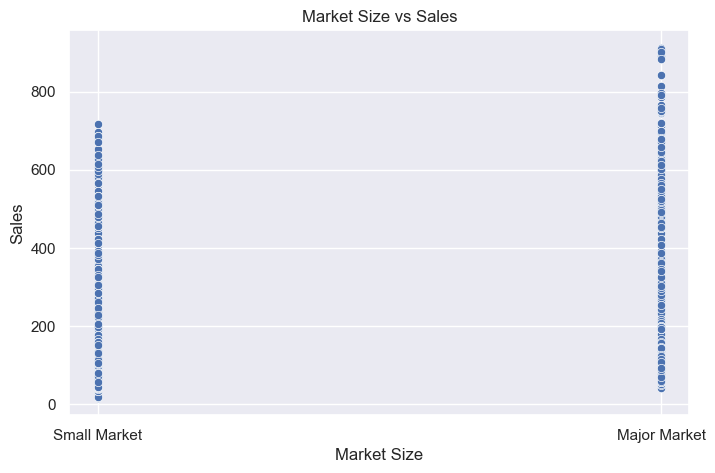

In [35]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Market Size', y='Sales', data=df)
plt.title("Market Size vs Sales")
plt.show()

### Correlation Matrix

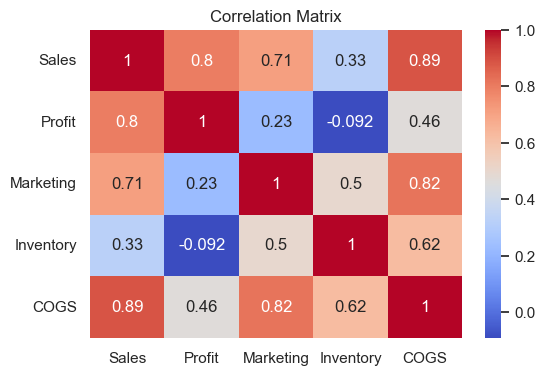

In [38]:
# Correlation Matrix
plt.figure(figsize=(6,4))
numeric_cols = ['Sales', 'Profit', 'Marketing', 'Inventory', 'COGS']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

- Correlation close to 1 = strong positive relationship
- Close to 0 = weak relationship

### Monthly Revenue Trend

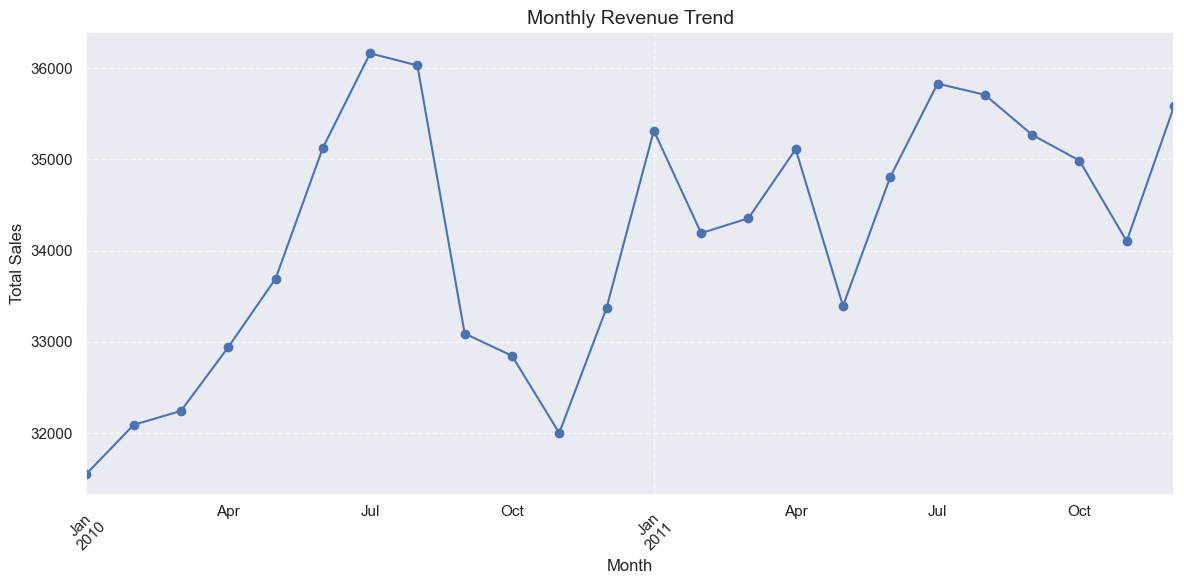

In [39]:
## Monthly Revenue Trend

df['Month'] = df['Date'].dt.to_period('M')

monthly_revenue = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(12,6))
monthly_revenue.plot(marker='o', linestyle='-', color='b')
plt.title("Monthly Revenue Trend", fontsize=14)
plt.ylabel("Total Sales", fontsize=12)
plt.xlabel("Month", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()